In [87]:
# ! pip install numpy
# ! pip install pandas
# ! pip install cvxpy
# ! pip install matplotlib
# ! pip install yfinance
# ! pip install plotly
# ! pip install --upgrade nbformat

In [88]:
import yfinance as yf
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

In [89]:
tickers = ["USDBRL=X", "EURBRL=X", "GBPBRL=X", "JPYBRL=X", "CHFBRL=X", "CADBRL=X"]
assets = ["Dólar", "Euro", "Libra", "Iene", "Franco", "Dólar Canadense"]
start = "2020-01-01"
end = "2026-01-01"

prices = yf.download(tickers, start=start, end=end)
# print(prices.head())
prices = prices["Close"]
prices = prices.dropna()
prices.head()

[*********************100%***********************]  6 of 6 completed


Ticker,CADBRL=X,CHFBRL=X,EURBRL=X,GBPBRL=X,JPYBRL=X,USDBRL=X
Date,,,,,,
2020-01-01,3.091440,4.149169,4.5033,5.327242,0.036959,4.016786
2020-01-02,3.081142,4.125845,4.4883,5.330490,0.036939,4.016300
2020-01-03,3.096767,4.139577,4.4920,5.288276,0.037059,4.023400
2020-01-06,3.126856,4.179195,4.5338,5.309599,0.037532,4.057000
2020-01-07,3.130540,4.190845,4.5434,5.347909,0.037453,4.060400


In [90]:
""" Métodos para visualização"""

def portfolio_stats(w, mu, Sigma, rf=0.03):
    ret = float(mu @ w) # Retorno do portfólio
    vol = float(np.sqrt(w.T @ Sigma @ w)) # Volatilidade do portfólio
    sharpe = (ret - rf) / vol if vol > 0 else np.nan # Sharpe com base no retorno
    return ret, vol, sharpe
    

def show_weights(w, title="Pesos"):
    # Exibição organizada dos ativos
    df = pd.DataFrame({"asset": assets, "weight": np.round(w, 4)})
    print(title)
    display(df)

In [91]:
returns = prices.pct_change().dropna()
log_returns = np.log(prices / prices.shift(1)).dropna()

returns.head()

Ticker,CADBRL=X,CHFBRL=X,EURBRL=X,GBPBRL=X,JPYBRL=X,USDBRL=X
Date,,,,,,
2020-01-02,-0.003331,-0.005621,-0.003331,0.000610,-0.000541,-0.000121
2020-01-03,0.005071,0.003328,0.000824,-0.007919,0.003249,0.001768
2020-01-06,0.009716,0.009571,0.009305,0.004032,0.012763,0.008351
2020-01-07,0.001178,0.002788,0.002117,0.007215,-0.002105,0.000838
2020-01-08,-0.001657,0.000636,-0.002465,-0.002958,0.004673,0.001428


In [92]:
mu_daily = returns.mean()
Sigma_daily = returns.cov()

mu_annual = mu_daily * 252
mu = mu_annual.to_numpy()
Sigma_annual = Sigma_daily * 252
Sigma = Sigma_annual.to_numpy()

print("Retorno: ", mu_annual)
print("Variância: ", Sigma_annual)

Retorno:  Ticker
CADBRL=X    0.054420
CHFBRL=X    0.098259
EURBRL=X    0.070338
GBPBRL=X    0.066609
JPYBRL=X    0.008997
USDBRL=X    0.063057
dtype: float64
Variância:  Ticker    CADBRL=X  CHFBRL=X  EURBRL=X  GBPBRL=X  JPYBRL=X  USDBRL=X
Ticker                                                              
CADBRL=X  0.026077  0.025748  0.020883  0.021770  0.022762  0.019988
CHFBRL=X  0.025748  0.031905  0.024631  0.024334  0.027857  0.022064
EURBRL=X  0.020883  0.024631  0.025912  0.021797  0.023450  0.020877
GBPBRL=X  0.021770  0.024334  0.021797  0.028748  0.026637  0.021791
JPYBRL=X  0.022762  0.027857  0.023450  0.026637  0.035604  0.024870
USDBRL=X  0.019988  0.022064  0.020877  0.021791  0.024870  0.026071


In [93]:
n = len(tickers)
w = cp.Variable(n)

risk = cp.quad_form(w, Sigma)
objective = cp.Minimize(risk)
constraints = [cp.sum(w) == 1, w >= 0]
prob = cp.Problem(objective, constraints)
prob.solve()

print(prob.status)

show_weights(w.value, "Mínima volatilidade")
w_minvar = w

ret, vol, sharpe = portfolio_stats(w_minvar.value, mu, Sigma, 0.0)
print("retorno:", ret)
print("volatilidade:", vol)
print("Sharpe:", sharpe)

optimal
Mínima volatilidade


,asset,weight
0,Dólar,0.3223
1,Euro,-0.0000
2,Libra,0.2755
3,Iene,0.0795
4,Franco,0.0000
5,Dólar Canadense,0.3227


retorno: 0.06256106141021832
volatilidade: 0.14946306847148944
Sharpe: 0.4185720395681027


In [94]:
rf = 0.0
w = cp.Variable(n)
ret = mu @ w
risk = cp.quad_form(w, Sigma)

prob = cp.Problem(cp.Maximize(ret - rf), [cp.sum(w) == 1, w >= 0, risk <= 0.03]) # Troque risco para 0.03
prob.solve(solver=cp.SCS)


w_maxret = w



print(prob.status)



show_weights(w.value, "Máximo retorno")

ret, vol, sharpe = portfolio_stats(w_maxret.value, mu, Sigma, rf)
print("retorno:", ret)
print("volatilidade:", vol)
print("Sharpe:", sharpe)

optimal
Máximo retorno


,asset,weight
0,Dólar,0.0000
1,Euro,0.8956
2,Libra,0.0000
3,Iene,0.0000
4,Franco,-0.0000
5,Dólar Canadense,0.1044


retorno: 0.09458319628768148
volatilidade: 0.17320823439067476
Sharpe: 0.546066395863993


In [95]:
""" Carteira de mínima variância com retorno alvo """

target_return = 0.07

w = cp.Variable(n)
objective = cp.Minimize(cp.quad_form(w, Sigma))
constraints = [
    cp.sum(w) == 1,
    w >= 0,
    mu @ w >= target_return
]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.OSQP)

print(prob.status)

show_weights(w.value, "Carteira de minima variância com retorno alvo")

w_tarret = w

ret, vol, sharpe = portfolio_stats(w_tarret.value, mu, Sigma, rf)
print("retorno:", ret)
print("volatilidade:", vol)
print("Sharpe:", sharpe)

optimal
Carteira de minima variância com retorno alvo


,asset,weight
0,Dólar,0.1204
1,Euro,0.1506
2,Libra,0.3182
3,Iene,0.1024
4,Franco,0.0000
5,Dólar Canadense,0.3084


retorno: 0.07
volatilidade: 0.1520411240747436
Sharpe: 0.4604017526573134


In [96]:
""" Carteira com grupo """

w = cp.Variable(n)
objective = cp.Minimize(cp.quad_form(w, Sigma))
constraints = [cp.sum(w) == 1, w >= 0]
constraints.append(cp.sum(w[[2, 4]]) >= 0.80)
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.OSQP)

w_group = w
show_weights(w_group.value, "Carteira com grupo")

ret, vol, sharpe = portfolio_stats(w_group.value, mu, Sigma, rf)
print("retorno:", ret)
print("volatilidade:", vol)
print("Sharpe:", sharpe)


Carteira com grupo


,asset,weight
0,Dólar,0.1164
1,Euro,0.0000
2,Libra,0.7031
3,Iene,0.0000
4,Franco,0.0969
5,Dólar Canadense,0.0836


retorno: 0.061929647644536095
volatilidade: 0.1550883111466537
Sharpe: 0.39931860232828603


In [97]:
""" Carteira com shrinkage """

alpha = 0.30
F = np.diag(np.diag(Sigma))
Sigma_shrink = (1 - alpha) * Sigma + alpha * F

w = cp.Variable(n)
objective = cp.Minimize(cp.quad_form(w, Sigma_shrink))
constraints = [cp.sum(w) == 1, w >= 0]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.OSQP)

w_shrink = w
show_weights(w_shrink.value, "Carteira com shrinkage")

ret, vol, sharpe = portfolio_stats(w_group.value, mu, Sigma, rf)
print("retorno:", ret)
print("volatilidade:", vol)
print("Sharpe:", sharpe)

Carteira com shrinkage


,asset,weight
0,Dólar,0.2541
1,Euro,0.0445
2,Libra,0.2450
3,Iene,0.1649
4,Franco,0.0316
5,Dólar Canadense,0.2598


retorno: 0.061929647644536095
volatilidade: 0.1550883111466537
Sharpe: 0.39931860232828603


In [98]:


stats = pd.DataFrame(
    {
        "min_var": portfolio_stats(w_minvar.value, mu, Sigma),
        "max_ret": portfolio_stats(w_maxret.value, mu, Sigma),
        "target": portfolio_stats(w_tarret.value, mu, Sigma),
        "group": portfolio_stats(w_group.value, mu, Sigma),
        "shrink": portfolio_stats(w_shrink.value, mu, Sigma),
    },
    index=["retorno", "risco", "sharpe"]
)

stats

,min_var,max_ret,target,group,shrink
retorno,0.062561,0.094583,0.070000,0.061930,0.063088
risco,0.149463,0.173208,0.152041,0.155088,0.150709
sharpe,0.217854,0.372864,0.263087,0.205880,0.219548


,strategy,return,vol,sharpe
0,mínima variância,0.062561,0.149463,0.418572
1,máximo retorno,0.094583,0.173208,0.546066
2,retorno alvo,0.070000,0.152041,0.460402
3,grupo,0.061930,0.155088,0.399319
4,shrinkage,0.094583,0.173208,0.546066


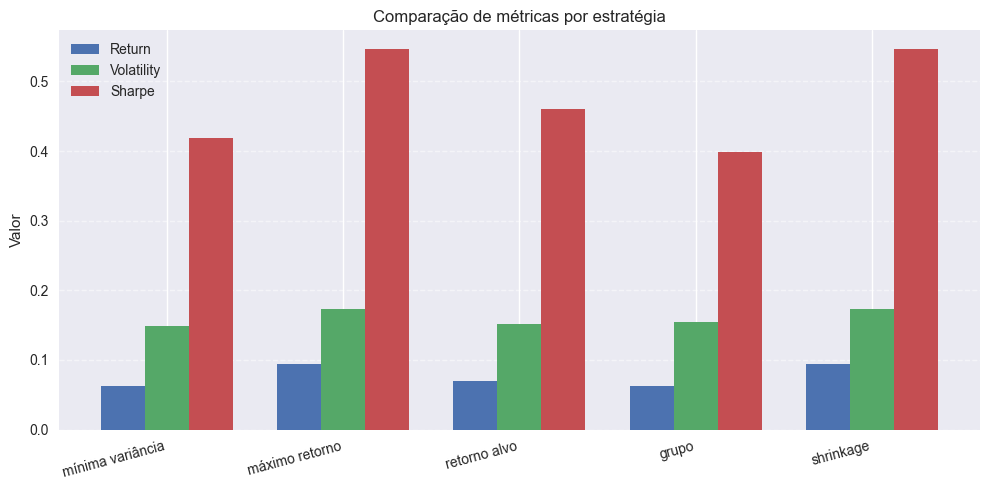

In [99]:
""" Comparando carteiras """

results = pd.DataFrame([
    ["mínima variância", *portfolio_stats(w_minvar.value, mu, Sigma, rf)],
    ["máximo retorno", *portfolio_stats(w_maxret.value, mu, Sigma, rf)],
    ["retorno alvo", *portfolio_stats(w_tarret.value, mu, Sigma, rf)],
    ["grupo", *portfolio_stats(w_group.value, mu, Sigma, rf)],
    ["shrinkage", *portfolio_stats(w_maxret.value, mu, Sigma, rf)],
], columns=["strategy", "return", "vol", "sharpe"])

display(results)

plt.figure(figsize=(10, 5))

xx = np.arange(len(results))
width = 0.25

plt.bar(xx - width, results["return"], width, label="Return")
plt.bar(xx, results["vol"], width, label="Volatility")
plt.bar(xx + width, results["sharpe"], width, label="Sharpe")

plt.xticks(xx, results["strategy"], rotation=15, ha="right")
plt.ylabel("Valor")
plt.title("Comparação de métricas por estratégia")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [100]:
import plotly.express as px

df_plot = results.copy()

df_long = df_plot.melt(
    id_vars="strategy",
    value_vars=["return", "vol", "sharpe"],
    var_name="métrica",
    value_name="valor"
)

fig = px.bar(
    df_long,
    x="strategy",
    y="valor",
    color="métrica",
    barmode="group",
    text_auto=True
)

fig.update_layout(
    title="Comparação das estratégias",
    xaxis_title="Estratégia",
    yaxis_title="Valor",
    legend_title="Métrica"
)

fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

weights_df = pd.DataFrame({
    "mínima variância": w_minvar.value, 
    "máximo retorno": w_maxret.value,
    "retorno alvo": w_tarret.value,
    "grupo": w_group.value,
    "shrinkage": w_shrink.value,
}, index=assets)

long_df = weights_df.reset_index().melt(
    id_vars=weights_df.index.name or "index",
    var_name="método",
    value_name="peso"
)

long_df = long_df.rename(columns={weights_df.index.name or "index": "ativo"})

fig = px.bar(
    long_df,
    x="método",
    y="peso",
    color="ativo",
    barmode="group",
    text_auto=".2%"
)

fig.update_layout(
    title="Alocação dos pesos por método",
    xaxis_title="Método",
    yaxis_title="Peso",
    legend_title="Ativo"
)

fig.update_traces(
    cliponaxis=False,
    marker_line_color='black',
    marker_line_width=1
)
fig.show()

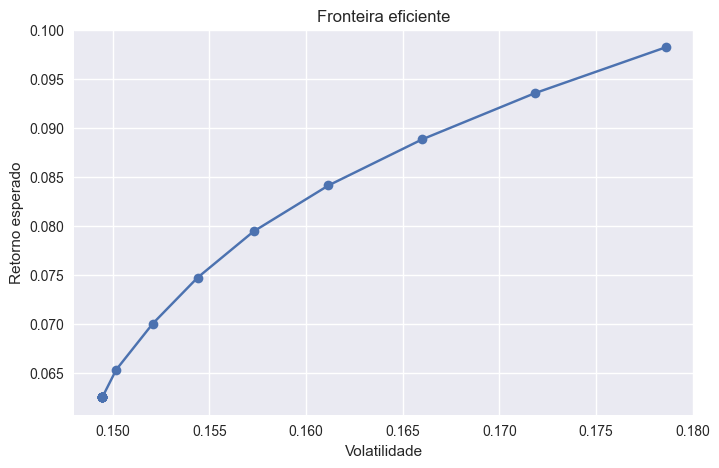

In [108]:
""" Fronteira eficiente """

targets = np.linspace(mu.min(), mu.max(), 20)
rets, vols = [], [] # Retornos e volatilidades
weights = []

for t in targets:
    w = cp.Variable(n)
    objective = cp.Minimize(cp.quad_form(w, Sigma))
    constraints = [cp.sum(w) == 1, w >= 0, mu @ w >= t]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP)
    
    if w.value is not None:
        weights.append(w.value)
        r, v, _ = portfolio_stats(w.value, mu, Sigma, rf)
        rets.append(r)
        vols.append(v)

plt.figure(figsize=(8, 5))
plt.plot(vols, rets, marker="o")
plt.xlabel("Volatilidade")
plt.ylabel("Retorno esperado")
plt.title("Fronteira eficiente")
plt.grid(True)
plt.show()

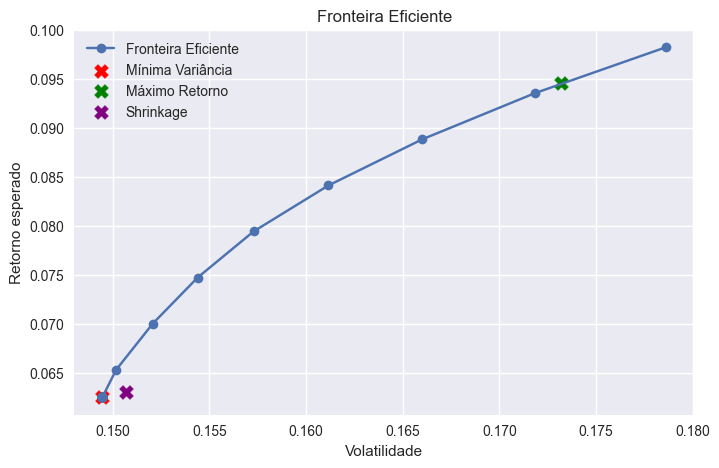

In [ ]:


plt.figure(figsize=(8, 5))
plt.plot(vols, rets, marker="o", label="Fronteira Eficiente") 

r_min, v_min, _ = portfolio_stats(w_minvar.value, mu, Sigma, rf)
r_max, v_max, _ = portfolio_stats(w_maxret.value, mu, Sigma, rf)
r_shrink, v_shrink, _ = portfolio_stats(w_shrink.value, mu, Sigma, rf)

plt.scatter(v_min, r_min, marker="X", color="red", s=100, label="Mínima Variância")
plt.scatter(v_max, r_max, marker="X", color="green", s=100, label="Máximo Retorno")
plt.scatter(v_shrink, r_shrink, marker="X", color="purple", s=100, label="Shrinkage")

plt.xlabel("Volatilidade")
plt.ylabel("Retorno esperado")
plt.title("Fronteira Eficiente")
plt.legend()
plt.grid(True)
plt.show()

Solvers
https://www.cvxpy.org/tutorial/solvers/index.html

In [ ]:
(mu*w*c)/(wT*Sigma*w)

In [ ]:


parity
budgeting
litterman
achar o alpha ótimo do shrinkage
    norma de frobenius
    como estimar uma matriz regularizada de shrinkage

rmt
pca, modelos de fatores



pedir as notas de aula e perguntar como vai ser a prova

